# Comparación de modelos y selección final

Este notebook consolida los experimentos realizados sólo con **train** y **validation**. La selección se fija antes de cargar test. El test se evalúa una sola vez y no se utiliza para cambiar la decisión.

In [1]:
from pathlib import Path
import json, subprocess
from datetime import datetime, timezone
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, classification_report,
                             confusion_matrix, f1_score, precision_score, recall_score)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
ROOT=Path.cwd().parent if Path.cwd().name=="experimentos" else Path.cwd()
PARCIALES=ROOT/"results/experimentos_parciales"
RESULTADOS=ROOT/"results/experimentos_entregable3.csv"
ARTIFACTS=ROOT/"artifacts"; ARTIFACTS.mkdir(exist_ok=True)
DATA=ROOT/"data/processed/modelado/dataset_modelado_nivel_actividad_firms.parquet"
SPLITS=ROOT/"data/processed/modelado/splits"
KEY=["departamento","fecha_inicio_semana"]; TARGET="nivel_actividad_firms"
ORDER=["Sin actividad","Bajo","Moderado","Alto"]; RS=42

## 1. Consolidación de experimentos

In [2]:
archivos=sorted(PARCIALES.glob("*.csv"))
assert len(archivos)==4, archivos
resultados=pd.concat([pd.read_csv(x) for x in archivos],ignore_index=True)
assert resultados.experiment_id.is_unique
resultados.to_csv(RESULTADOS,index=False)
columnas=["experiment_id","modelo","variante_variables","f1_macro_validation","balanced_accuracy_validation","recall_macro_validation","accuracy_validation"]
display(resultados.sort_values("f1_macro_validation",ascending=False)[columnas])

,experiment_id,modelo,variante_variables,f1_macro_validation,balanced_accuracy_validation,recall_macro_validation,accuracy_validation
15,rf_tuned_v1,RandomForest,V1,0.405157,0.425738,0.425738,0.574916
11,rf_base_v1,RandomForest,V1,0.392312,0.392420,0.392420,0.616162
13,rf_base_v3,RandomForest,V3,0.377102,0.374152,0.374152,0.611953
14,rf_base_v4,RandomForest,V4,0.374994,0.369880,0.369880,0.612795
6,lr_tuned_v3_c0.1_cwbalanced,LogisticRegression,V3,0.364105,0.422908,0.422908,0.490741
18,hgb_base_v3,HistGradientBoosting,V3,0.356504,0.350467,0.350467,0.624579
12,rf_base_v2,RandomForest,V2,0.356187,0.354067,0.354067,0.607744
10,lr_tuned_v3_c10.0_cwbalanced,LogisticRegression,V3,0.353820,0.410212,0.410212,0.478114
8,lr_tuned_v3_c1.0_cwbalanced,LogisticRegression,V3,0.352887,0.409877,0.409877,0.477273
3,lr_base_v3,LogisticRegression,V3,0.352887,0.409877,0.409877,0.477273


## 2. Comparación V1–V4

V1 usa contexto y meteorología; V2 agrega lags FIRMS; V3 agrega rolling FIRMS; V4 incorpora ambos tipos de historia.

variante_variables,V1,V2,V3,V4
modelo,,,,
HistGradientBoosting,0.349667,0.347218,0.356504,0.350898
LogisticRegression,0.350545,0.350553,0.352887,0.352794
RandomForest,0.392312,0.356187,0.377102,0.374994


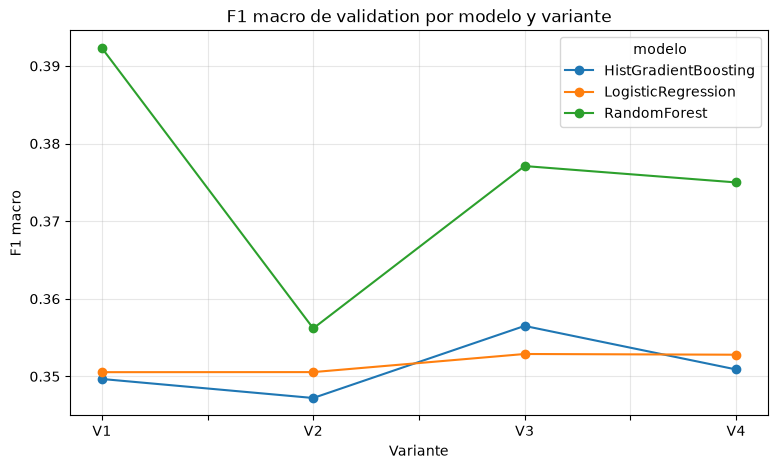

,experiment_id,modelo,variante_variables,f1_macro_validation,balanced_accuracy_validation,recall_macro_validation,accuracy_validation
0,dummy_most_frequent,DummyClassifier,None,0.192706,0.250000,0.250000,0.627104
1,hgb_base_v3,HistGradientBoosting,V3,0.356504,0.350467,0.350467,0.624579
2,lr_tuned_v3_c0.1_cwbalanced,LogisticRegression,V3,0.364105,0.422908,0.422908,0.490741
3,rf_tuned_v1,RandomForest,V1,0.405157,0.425738,0.425738,0.574916


In [3]:
base=resultados[resultados.experiment_id.str.contains("_base_")].copy()
tabla_variantes=base.pivot(index="modelo",columns="variante_variables",values="f1_macro_validation")
display(tabla_variantes)
ax=tabla_variantes.T.plot(marker="o",figsize=(9,5));ax.set(title="F1 macro de validation por modelo y variante",xlabel="Variante",ylabel="F1 macro");ax.grid(alpha=.3);plt.show()
mejores=resultados.sort_values("f1_macro_validation",ascending=False).groupby("modelo",as_index=False).first()
display(mejores[columnas])

## 3. Solución fijada antes de test

Se selecciona **Random Forest ajustado con V1**. Presenta el mayor F1 macro de validation (criterio principal), la mayor Balanced Accuracy entre las configuraciones ejecutadas y supera claramente al Dummy. V1 además es más simple y no depende de historia FIRMS. No se construye un ranking artificial con pesos.

Esta decisión queda congelada aquí. Los resultados posteriores de test no se usarán para cambiarla.

In [4]:
SELECTED_ID="rf_tuned_v1"
seleccion=resultados.set_index("experiment_id").loc[SELECTED_ID]
assert seleccion.modelo=="RandomForest" and seleccion.variante_variables=="V1"
PARAMS=json.loads(seleccion.hiperparametros)
FEATURES=["departamento","mes","temperature_2m_max_mean_weekly","relative_humidity_2m_min_mean_weekly","wind_speed_10m_max_mean_weekly","precipitation_sum_weekly"]
PROHIBITED={"cantidad_detecciones","fecha_inicio_semana","anio","numero_semana",TARGET,"nivel_actividad_firms_codigo","presencia_firms"}
assert PROHIBITED.isdisjoint(FEATURES)
print("Selección congelada:",SELECTED_ID,PARAMS,FEATURES)

Selección congelada: rf_tuned_v1 {'class_weight': 'balanced_subsample', 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 5, 'n_estimators': 500, 'n_jobs': -1, 'random_state': 42} ['departamento', 'mes', 'temperature_2m_max_mean_weekly', 'relative_humidity_2m_min_mean_weekly', 'wind_speed_10m_max_mean_weekly', 'precipitation_sum_weekly']


## 4. Explicabilidad en validation (sin test)

,variable,importancia_media,desviacion
1,mes,0.068203,0.011670
0,departamento,0.065692,0.009557
3,relative_humidity_2m_min_mean_weekly,0.065322,0.007341
2,temperature_2m_max_mean_weekly,0.043928,0.007622
5,precipitation_sum_weekly,0.019604,0.008194
4,wind_speed_10m_max_mean_weekly,0.016759,0.005518


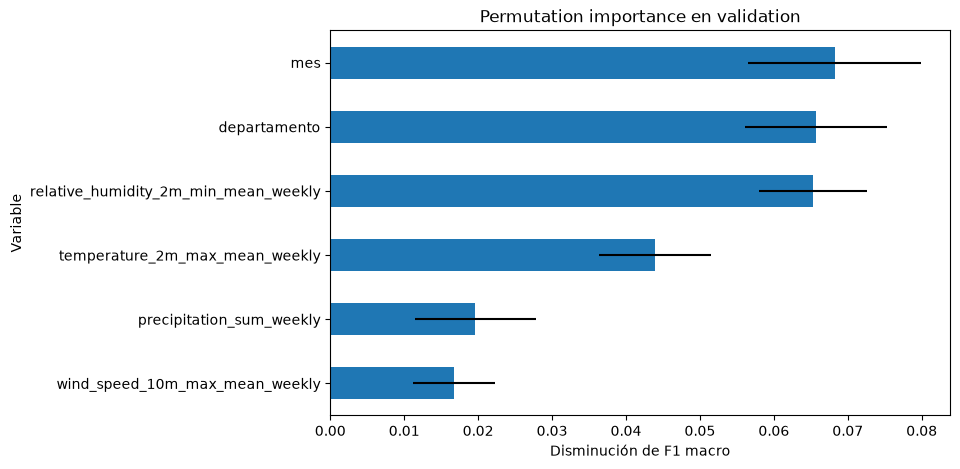

In [5]:
datos=pd.read_parquet(DATA);datos.fecha_inicio_semana=pd.to_datetime(datos.fecha_inicio_semana)
def subset(name):
    k=pd.read_parquet(SPLITS/f"{name}_keys.parquet");k.fecha_inicio_semana=pd.to_datetime(k.fecha_inicio_semana)
    return datos.merge(k,on=KEY,how="inner",validate="one_to_one")
train=subset("train");validation=subset("validation")
def build_final():
    pre=ColumnTransformer([("cat",OneHotEncoder(handle_unknown="ignore"),["departamento","mes"]),("num","passthrough",FEATURES[2:])])
    return Pipeline([("pre",pre),("model",RandomForestClassifier(**PARAMS))])
modelo_desarrollo=build_final().fit(train[FEATURES],train[TARGET])
perm=permutation_importance(modelo_desarrollo,validation[FEATURES],validation[TARGET],n_repeats=10,random_state=RS,scoring="f1_macro",n_jobs=-1)
importancias=pd.DataFrame({"variable":FEATURES,"importancia_media":perm.importances_mean,"desviacion":perm.importances_std}).sort_values("importancia_media",ascending=False)
display(importancias)
ax=importancias.sort_values("importancia_media").plot.barh(x="variable",y="importancia_media",xerr="desviacion",legend=False,figsize=(8,5));ax.set(title="Permutation importance en validation",xlabel="Disminución de F1 macro",ylabel="Variable");plt.show()

## 5. Evaluación final única sobre test

A partir de esta celda se carga test. La solución ya está fijada.

In [6]:
test=subset("test")
desarrollo=pd.concat([train,validation],ignore_index=True)
assert len(desarrollo)==6734 and len(test)==1189
modelo_final=build_final().fit(desarrollo[FEATURES],desarrollo[TARGET])
pred_test=modelo_final.predict(test[FEATURES])
proba_test=modelo_final.predict_proba(test[FEATURES])
def metricas(y,p):
    r=classification_report(y,p,labels=ORDER,output_dict=True,zero_division=0)
    return {"accuracy":accuracy_score(y,p),"balanced_accuracy":balanced_accuracy_score(y,p),"precision_macro":precision_score(y,p,average="macro",zero_division=0),"recall_macro":recall_score(y,p,average="macro",zero_division=0),"f1_macro":f1_score(y,p,average="macro",zero_division=0),"f1_weighted":f1_score(y,p,average="weighted",zero_division=0),**{f"precision_{x.lower().replace(' ','_')}":r[x]["precision"] for x in ORDER},**{f"recall_{x.lower().replace(' ','_')}":r[x]["recall"] for x in ORDER},**{f"f1_{x.lower().replace(' ','_')}":r[x]["f1-score"] for x in ORDER}}
metricas_test=metricas(test[TARGET],pred_test)
display(pd.DataFrame([metricas_test]))
cm=confusion_matrix(test[TARGET],pred_test,labels=ORDER)
display(pd.DataFrame(cm,index=ORDER,columns=ORDER))
display(pd.DataFrame(classification_report(test[TARGET],pred_test,labels=ORDER,output_dict=True,zero_division=0)).T)

,accuracy,balanced_accuracy,precision_macro,recall_macro,f1_macro,f1_weighted,precision_sin_actividad,precision_bajo,precision_moderado,precision_alto,recall_sin_actividad,recall_bajo,recall_moderado,recall_alto,f1_sin_actividad,f1_bajo,f1_moderado,f1_alto
0,0.555929,0.413745,0.388613,0.413745,0.396723,0.571963,0.78852,0.240196,0.308756,0.216981,0.700671,0.263441,0.352632,0.338235,0.742004,0.251282,0.329238,0.264368


,Sin actividad,Bajo,Moderado,Alto
Sin actividad,522,106,84,33
Bajo,72,49,46,19
Moderado,53,39,67,31
Alto,15,10,20,23


,precision,recall,f1-score,support
Sin actividad,0.788520,0.700671,0.742004,745.000000
Bajo,0.240196,0.263441,0.251282,186.000000
Moderado,0.308756,0.352632,0.329238,190.000000
Alto,0.216981,0.338235,0.264368,68.000000
accuracy,0.555929,0.555929,0.555929,0.555929
macro avg,0.388613,0.413745,0.396723,1189.000000
weighted avg,0.593391,0.555929,0.571963,1189.000000


## 6. Comparación final contra Dummy

In [7]:
dummy=DummyClassifier(strategy="most_frequent",random_state=RS).fit(np.ones((len(desarrollo),1)),desarrollo[TARGET])
pred_dummy=dummy.predict(np.ones((len(test),1)))
comparacion_test=pd.DataFrame([{"modelo":"Dummy",**metricas(test[TARGET],pred_dummy)},{"modelo":"Random Forest V1",**metricas_test}])
display(comparacion_test[["modelo","accuracy","balanced_accuracy","recall_macro","f1_macro","f1_weighted"]])

,modelo,accuracy,balanced_accuracy,recall_macro,f1_macro,f1_weighted
0,Dummy,0.626577,0.250000,0.250000,0.192606,0.482730
1,Random Forest V1,0.555929,0.413745,0.413745,0.396723,0.571963


## 7. Análisis de errores y distancia ordinal

In [8]:
errores=pd.DataFrame({"real":test[TARGET].to_numpy(),"predicho":pred_test})
cruce=pd.crosstab(errores.real,errores.predicho).reindex(index=ORDER,columns=ORDER,fill_value=0)
display(cruce)
confusiones={"Sin actividad → Bajo":int(cruce.loc["Sin actividad","Bajo"]),"Bajo → Sin actividad":int(cruce.loc["Bajo","Sin actividad"]),"Bajo → Moderado":int(cruce.loc["Bajo","Moderado"])}
print(confusiones)
codigo={x:i for i,x in enumerate(ORDER)}
errores["distancia_ordinal"]=(errores.real.map(codigo)-errores.predicho.map(codigo)).abs()
distancias=errores.distancia_ordinal.value_counts().sort_index().rename_axis("distancia").to_frame("cantidad")
distancias["porcentaje"]=100*distancias.cantidad/len(errores)
display(distancias)
print("Errores no adyacentes:",int((errores.distancia_ordinal>=2).sum()))

predicho,Sin actividad,Bajo,Moderado,Alto
real,,,,
Sin actividad,522,106,84,33
Bajo,72,49,46,19
Moderado,53,39,67,31
Alto,15,10,20,23


{'Sin actividad → Bajo': 106, 'Bajo → Sin actividad': 72, 'Bajo → Moderado': 46}


,cantidad,porcentaje
distancia,,
0,661,55.592935
1,314,26.408747
2,166,13.961312
3,48,4.037006


Errores no adyacentes: 214


## 8. Serialización y metadata

In [9]:
ruta_modelo=ARTIFACTS/"modelo_final.joblib";joblib.dump(modelo_final,ruta_modelo)
try: commit=subprocess.check_output(["git","rev-parse","HEAD"],cwd=ROOT,text=True).strip()
except Exception: commit="no disponible"
meta={"nombre_modelo":"RandomForestClassifier V1","fecha_generacion":datetime.now(timezone.utc).isoformat(),"version_proyecto":"Entregable 3","target":TARGET,"clases":ORDER,"variables":FEATURES,"hiperparametros":PARAMS,"random_state":RS,"dataset_entrenamiento":str(DATA.relative_to(ROOT)),"cantidad_filas_entrenamiento":len(desarrollo),"metricas_validation":{k:float(seleccion[k]) for k in ["accuracy_validation","balanced_accuracy_validation","precision_macro_validation","recall_macro_validation","f1_macro_validation","f1_weighted_validation"]},"metricas_test":{k:float(v) for k,v in metricas_test.items()},"ruta_modelo":str(ruta_modelo.relative_to(ROOT)),"git_commit":commit,"version_sklearn":sklearn.__version__,"version_pandas":pd.__version__,"split":{"train":5546,"validation":1188,"test":1189,"random_state":RS,"stratify":TARGET},"prohibidas":sorted(PROHIBITED)}
(ARTIFACTS/"metadata_modelo.json").write_text(json.dumps(meta,indent=2,ensure_ascii=False),encoding="utf-8")
demo=test[FEATURES].head(5).copy();demo.to_parquet(ROOT/"app/demo_examples.parquet",index=False)
print("Modelo y metadata guardados")

Modelo y metadata guardados


## Conclusión

La selección se basó sólo en validation. Random Forest V1 ofreció el mejor compromiso observado entre F1 macro, Balanced Accuracy, simplicidad e independencia de antecedentes FIRMS. La evaluación de test es una estimación final y no reabre la selección. Las importancias describen aporte predictivo, no causalidad.